In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.datasets import macrodata

In [2]:
data = macrodata.load_pandas().data
print("Dataset Head:")
data.head()

Dataset Head:


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


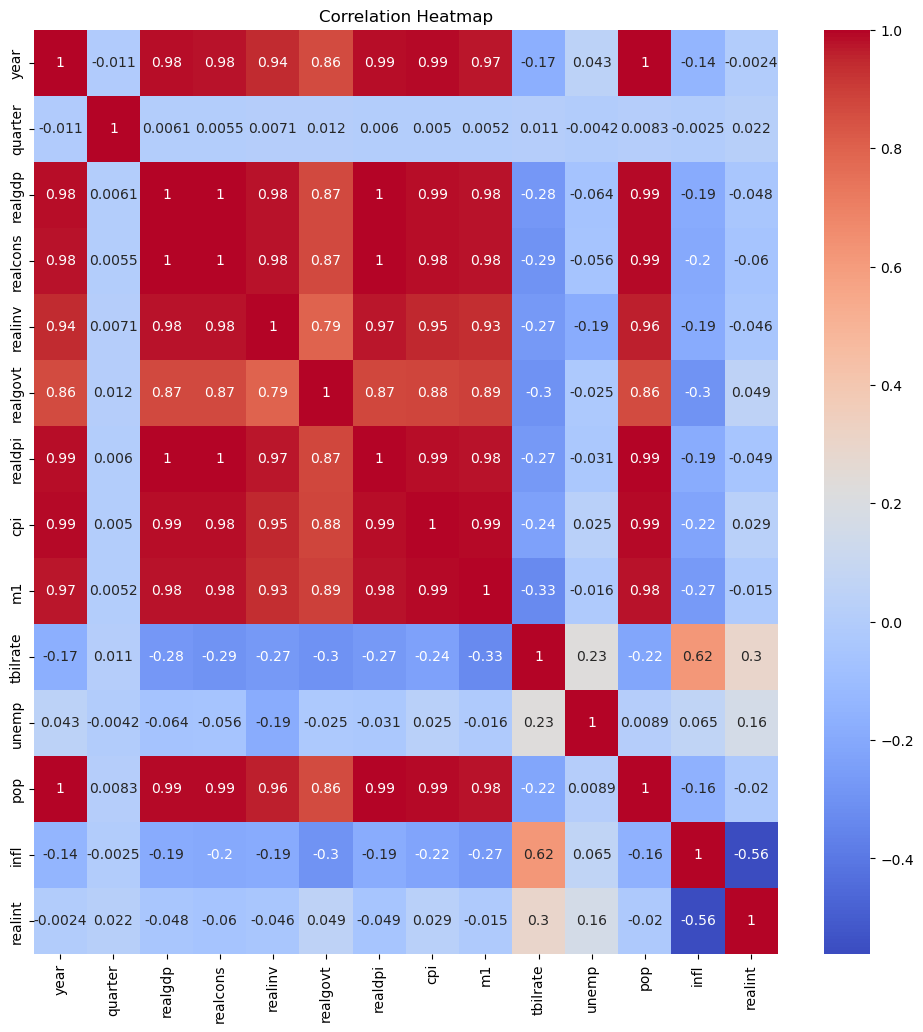

In [12]:
plt.figure(figsize=(12,12))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
pd.period_range(start='1959Q1', periods=len(df), freq='Q').to_timestamp() 

DatetimeIndex(['1959-01-01', '1959-04-01', '1959-07-01', '1959-10-01',
               '1960-01-01', '1960-04-01', '1960-07-01', '1960-10-01',
               '1961-01-01', '1961-04-01',
               ...
               '2007-04-01', '2007-07-01', '2007-10-01', '2008-01-01',
               '2008-04-01', '2008-07-01', '2008-10-01', '2009-01-01',
               '2009-04-01', '2009-07-01'],
              dtype='datetime64[ns]', length=203, freq='QS-OCT')

In [3]:
df = data[["realgdp", "infl", "unemp"]]
df.index = pd.period_range(start='1959Q1', periods=len(df), freq='Q')
df.index = df.index.to_timestamp() 

In [4]:
df.head()

,realgdp,infl,unemp
1959-01-01,2710.349,0.00,5.8
1959-04-01,2778.801,2.34,5.1
1959-07-01,2775.488,2.74,5.3
1959-10-01,2785.204,0.27,5.6
1960-01-01,2847.699,2.31,5.2


In [5]:
df.tail()

,realgdp,infl,unemp
2008-07-01,13324.600,-3.16,6.0
2008-10-01,13141.920,-8.79,6.9
2009-01-01,12925.410,0.94,8.1
2009-04-01,12901.504,3.37,9.2
2009-07-01,12990.341,3.56,9.6


In [8]:
print("\nData Info:")
print(df.info())
print("\nMissing Values:", df.isnull().sum())


Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 203 entries, 1959-01-01 to 2009-07-01
Freq: QS-OCT
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   realgdp  203 non-null    float64
 1   infl     203 non-null    float64
 2   unemp    203 non-null    float64
dtypes: float64(3)
memory usage: 6.3 KB
None

Missing Values: realgdp    0
infl       0
unemp      0
dtype: int64


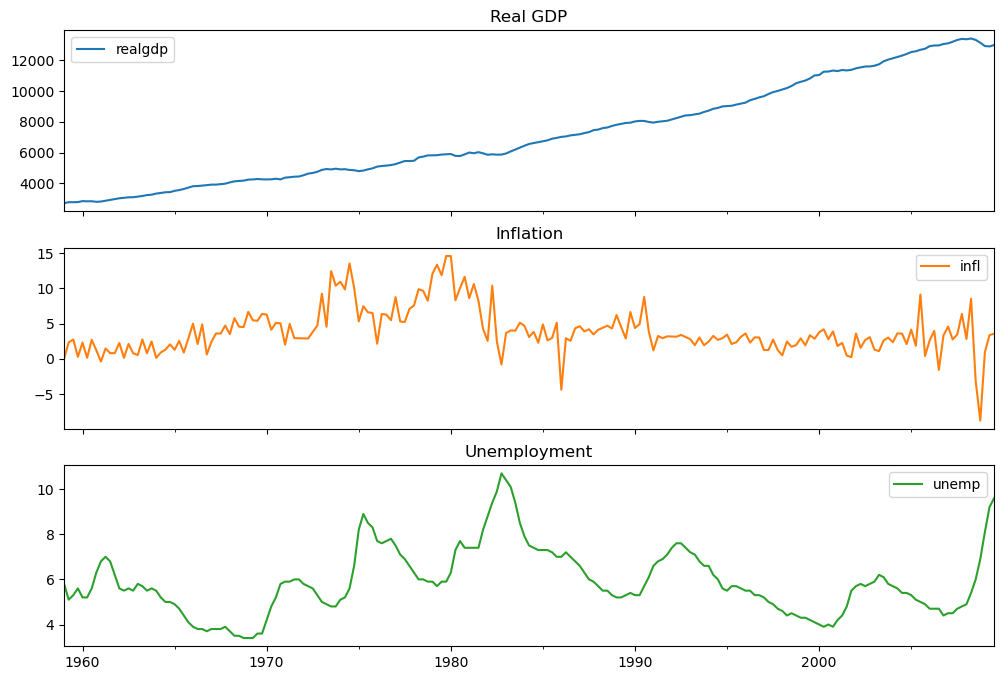

In [9]:
df.plot(subplots=True, figsize=(12, 8), title=["Real GDP", "Inflation", "Unemployment"])
plt.show()

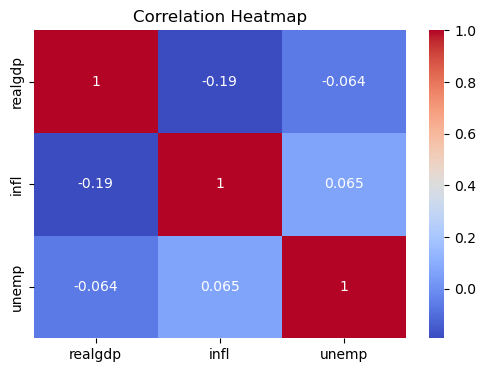

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
def adf_test(series, title=""):
    """
    Perform Augmented Dickey-Fuller test
    """
    print(f"Results of ADF Test for {title}")
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    out = pd.Series(result[0:4], index=labels)
    for key,val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out)
    if result[1] <= 0.05:
        print("=> Stationary (Reject H0)\n")
    else:
        print("=> Non-Stationary (Fail to Reject H0)\n")

In [14]:
for col in df.columns:
    adf_test(df[col], title=col)

Results of ADF Test for realgdp
ADF Test Statistic               1.750463
p-value                          0.998246
#Lags Used                      12.000000
Number of Observations Used    190.000000
Critical Value (1%)             -3.465244
Critical Value (5%)             -2.876875
Critical Value (10%)            -2.574945
dtype: float64
=> Non-Stationary (Fail to Reject H0)

Results of ADF Test for infl
ADF Test Statistic              -3.054514
p-value                          0.030108
#Lags Used                       2.000000
Number of Observations Used    200.000000
Critical Value (1%)             -3.463476
Critical Value (5%)             -2.876102
Critical Value (10%)            -2.574532
dtype: float64
=> Stationary (Reject H0)

Results of ADF Test for unemp
ADF Test Statistic              -2.536458
p-value                          0.106854
#Lags Used                       9.000000
Number of Observations Used    193.000000
Critical Value (1%)             -3.464694
Critical Value 

In [16]:
df_diff = df.diff().dropna()
df_diff

,realgdp,infl,unemp
1959-04-01,68.452,2.34,-0.7
1959-07-01,-3.313,0.40,0.2
1959-10-01,9.716,-2.47,0.3
1960-01-01,62.495,2.04,-0.4
1960-04-01,-13.309,-2.17,0.0
...,...,...,...
2008-07-01,-90.666,-11.69,0.6
2008-10-01,-182.680,-5.63,0.9
2009-01-01,-216.510,9.73,1.2
2009-04-01,-23.906,2.43,1.1


In [17]:
for col in df_diff.columns:
    adf_test(df_diff[col], title=f"{col} (1st Difference)")

Results of ADF Test for realgdp (1st Difference)
ADF Test Statistic            -6.305696e+00
p-value                        3.327882e-08
#Lags Used                     1.000000e+00
Number of Observations Used    2.000000e+02
Critical Value (1%)           -3.463476e+00
Critical Value (5%)           -2.876102e+00
Critical Value (10%)          -2.574532e+00
dtype: float64
=> Stationary (Reject H0)

Results of ADF Test for infl (1st Difference)
ADF Test Statistic            -1.715566e+01
p-value                        6.895349e-30
#Lags Used                     1.000000e+00
Number of Observations Used    2.000000e+02
Critical Value (1%)           -3.463476e+00
Critical Value (5%)           -2.876102e+00
Critical Value (10%)          -2.574532e+00
dtype: float64
=> Stationary (Reject H0)

Results of ADF Test for unemp (1st Difference)
ADF Test Statistic              -4.168475
p-value                          0.000745
#Lags Used                       8.000000
Number of Observations Used    1

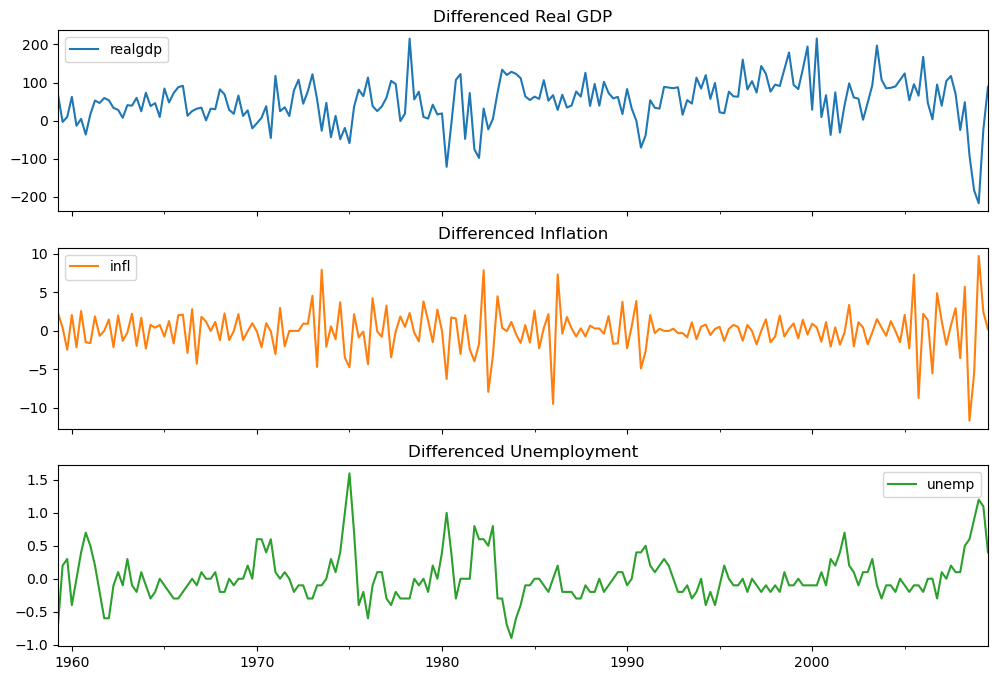

In [18]:
df_diff.plot(subplots=True, figsize=(12, 8), title=["Differenced Real GDP", "Differenced Inflation", "Differenced Unemployment"])
plt.show()

In [19]:
n_obs = 10  # last 10 periods as test
train = df_diff[:-n_obs]
test = df_diff[-n_obs:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (192, 3)
Test Shape: (10, 3)


In [20]:
model = VAR(train)

In [22]:
model.endog_names

['realgdp', 'infl', 'unemp']

In [23]:
lag_order_results = model.select_order(maxlags=10)

In [24]:
lag_order_results.summary()

,AIC,BIC,FPE,HQIC
0,7.074,7.126,1180.,7.095
1,6.276,6.487,531.5,6.361
2,5.994*,6.364*,401.1*,6.144*
3,6.045,6.574,422.3,6.259
4,6.030,6.716,415.9,6.308
5,6.088,6.933,441.3,6.431
6,6.120,7.124,456.1,6.527
7,6.152,7.314,471.4,6.623
8,6.162,7.482,476.9,6.697
9,6.186,7.665,489.5,6.785


In [26]:
lag_order_results.bic

2

In [27]:
optimal_lag = lag_order_results.aic
results = model.fit(optimal_lag)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Oct, 2025
Time:                     15:43:50
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    6.33586
Nobs:                     190.000    HQIC:                   6.12235
Log likelihood:          -1355.61    FPE:                    394.286
AIC:                      5.97698    Det(Omega_mle):         353.731
--------------------------------------------------------------------
Results for equation realgdp
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const             28.385243         6.830377            4.156           0.000
L1.realgdp         0.157976         0.081831            1.931           0.054
L1.infl           -1.957495         1.744191           -1.122         

In [28]:
results.k_ar

2

In [30]:
train.values[-2:]

array([[94.763,  4.88 , -0.3  ],
       [39.222,  1.28 ,  0.1  ]])

In [32]:
n_obs

10

In [33]:
lag_order = results.k_ar
forecast_input = train.values[-lag_order:]
forecast = results.forecast(y=forecast_input, steps=n_obs)
forecast_df = pd.DataFrame(forecast, index=test.index, columns=df.columns)
print("\nForecasted Values:")
print(forecast_df)


Forecasted Values:
              realgdp      infl     unemp
2007-04-01  29.948802 -3.867881  0.253754
2007-07-01  42.274358  1.926743  0.153231
2007-10-01  56.613655  0.058162 -0.007932
2008-01-01  52.998991 -0.801356  0.038718
2008-04-01  54.271444  0.506994  0.010434
2008-07-01  56.742920 -0.032184 -0.019289
2008-10-01  54.963529 -0.149293 -0.003255
2009-01-01  55.084087  0.129567 -0.008338
2009-04-01  55.312651 -0.012674 -0.011841
2009-07-01  54.799624 -0.022408 -0.006854


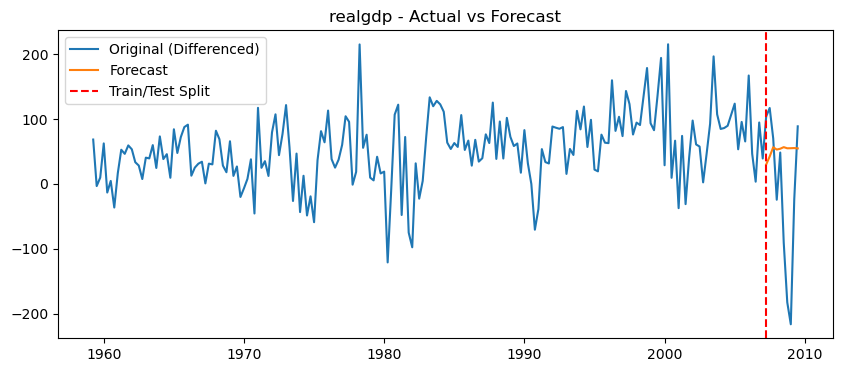

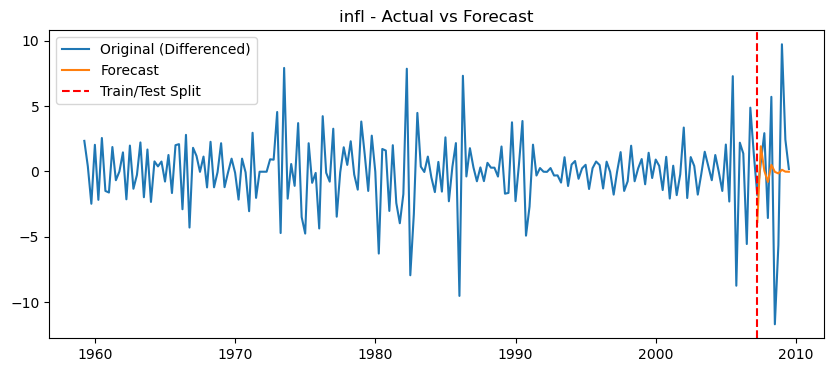

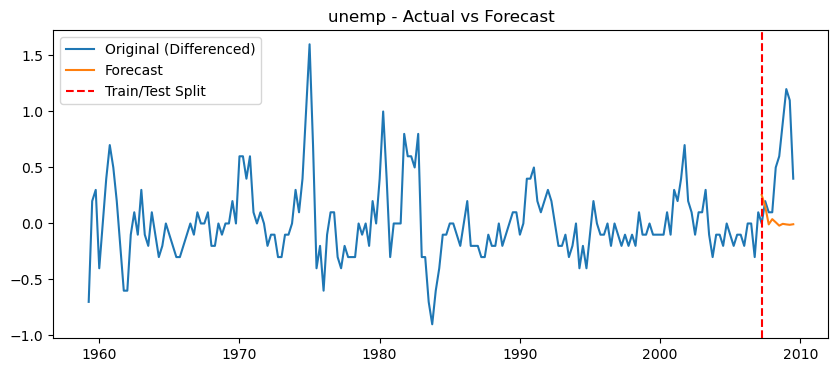

In [34]:
for col in df.columns:
    plt.figure(figsize=(10,4))
    plt.plot(df_diff.index, df_diff[col], label="Original (Differenced)")
    plt.plot(forecast_df.index, forecast_df[col], label="Forecast")
    plt.axvline(test.index[0], color='r', linestyle='--', label="Train/Test Split")
    plt.title(f"{col} - Actual vs Forecast")
    plt.legend()
    plt.show()

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
for col in df.columns:
    rmse = np.sqrt(mean_squared_error(test[col], forecast_df[col]))
    mae = mean_absolute_error(test[col], forecast_df[col])
    print(f"{col}: RMSE={rmse:.3f}, MAE={mae:.3f}")

realgdp: RMSE=132.931, MAE=101.567
infl: RMSE=5.592, MAE=4.349
unemp: RMSE=0.662, MAE=0.521


In [37]:
df.tail(12)

,realgdp,infl,unemp
2006-10-01,13060.679,3.30,4.4
2007-01-01,13099.901,4.58,4.5
2007-04-01,13203.977,2.75,4.5
2007-07-01,13321.109,3.45,4.7
2007-10-01,13391.249,6.38,4.8
2008-01-01,13366.865,2.82,4.9
2008-04-01,13415.266,8.53,5.4
2008-07-01,13324.600,-3.16,6.0
2008-10-01,13141.920,-8.79,6.9
2009-01-01,12925.410,0.94,8.1


In [36]:
df.iloc[-n_obs - 1]

realgdp    13099.901
infl           4.580
unemp          4.500
Name: 2007-01-01 00:00:00, dtype: float64

In [38]:
last_train_obs = df.iloc[-n_obs - 1]
forecast_orig = []
prev = last_train_obs.copy()

for i in range(len(forecast_df)):
    new_values = prev + forecast_df.iloc[i]
    forecast_orig.append(new_values)
    prev = new_values

forecast_orig_df = pd.DataFrame(forecast_orig, index=test.index, columns=df.columns)

In [40]:
forecast_df

,realgdp,infl,unemp
2007-04-01,29.948802,-3.867881,0.253754
2007-07-01,42.274358,1.926743,0.153231
2007-10-01,56.613655,0.058162,-0.007932
2008-01-01,52.998991,-0.801356,0.038718
2008-04-01,54.271444,0.506994,0.010434
2008-07-01,56.742920,-0.032184,-0.019289
2008-10-01,54.963529,-0.149293,-0.003255
2009-01-01,55.084087,0.129567,-0.008338
2009-04-01,55.312651,-0.012674,-0.011841
2009-07-01,54.799624,-0.022408,-0.006854


In [39]:
forecast_orig_df

,realgdp,infl,unemp
2007-04-01,13129.849802,0.712119,4.753754
2007-07-01,13172.124160,2.638862,4.906985
2007-10-01,13228.737815,2.697023,4.899053
2008-01-01,13281.736806,1.895668,4.937771
2008-04-01,13336.008249,2.402661,4.948205
2008-07-01,13392.751170,2.370477,4.928916
2008-10-01,13447.714699,2.221184,4.925661
2009-01-01,13502.798786,2.350751,4.917323
2009-04-01,13558.111437,2.338076,4.905482
2009-07-01,13612.911061,2.315668,4.898628


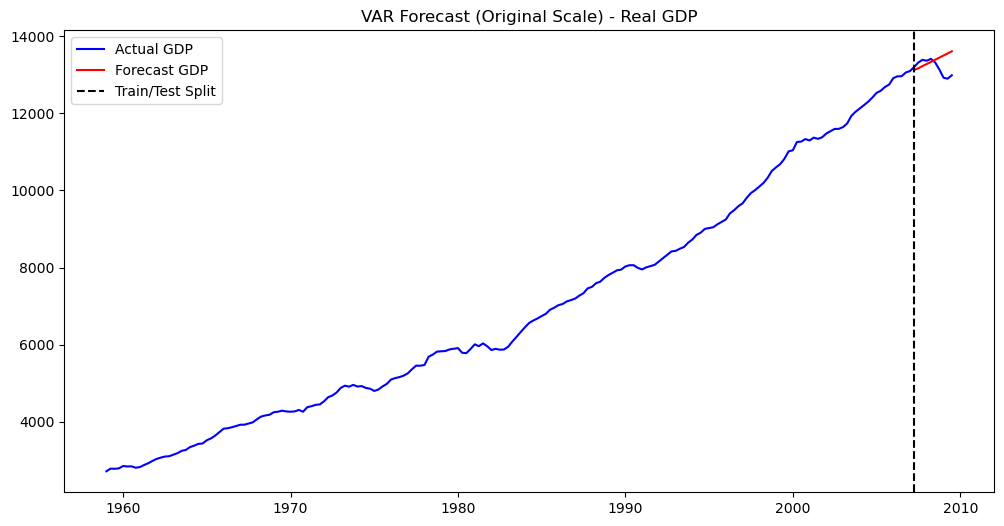

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(df['realgdp'], label="Actual GDP", color="blue")
plt.plot(forecast_orig_df['realgdp'], label="Forecast GDP", color="red")
plt.axvline(df.index[-n_obs], color="black", linestyle="--", label="Train/Test Split")
plt.legend()
plt.title("VAR Forecast (Original Scale) - Real GDP")
plt.show()

In [ ]:
df

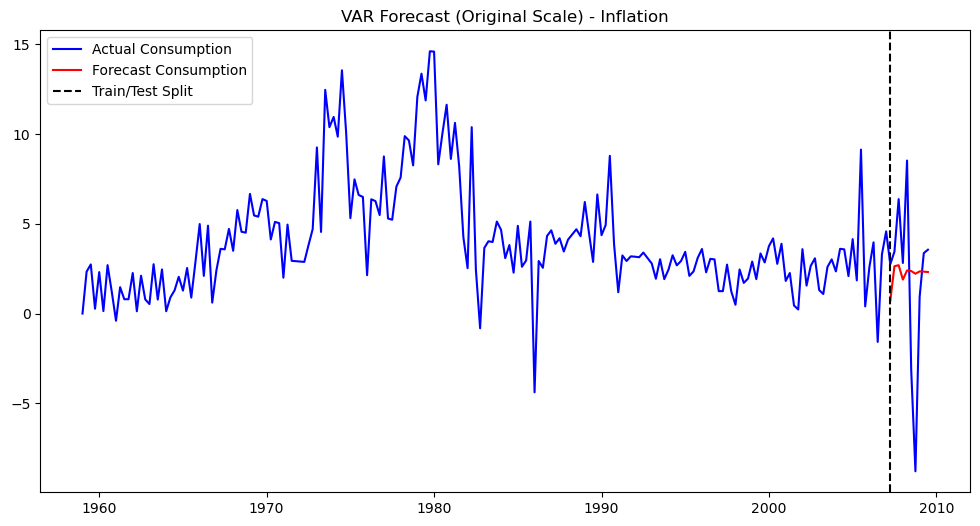

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(df['infl'], label="Actual Consumption", color="blue")
plt.plot(forecast_orig_df['infl'], label="Forecast Consumption", color="red")
plt.axvline(df.index[-n_obs], color="black", linestyle="--", label="Train/Test Split")
plt.legend()
plt.title("VAR Forecast (Original Scale) - Inflation")
plt.show()

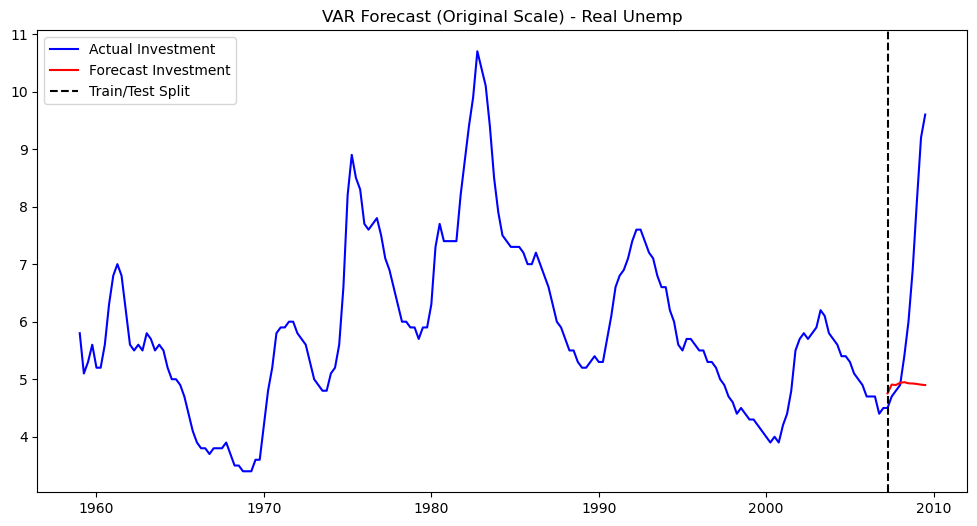

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(df['unemp'], label="Actual Investment", color="blue")
plt.plot(forecast_orig_df['unemp'], label="Forecast Investment", color="red")
plt.axvline(df.index[-n_obs], color="black", linestyle="--", label="Train/Test Split")
plt.legend()
plt.title("VAR Forecast (Original Scale) - Real Unemp")
plt.show()